In [1]:
!pip install -q ultralytics

import torch
import os
import yaml
import numpy as np
from ultralytics import YOLO

# Safe GPU Check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla P100-PCIE-16GB


In [2]:
DATA_YAML = "/kaggle/input/dental-opg/dataset/data.yaml"

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print(data_config)


{'train': '/kaggle/input/dental-opg/dataset/train/images', 'val': '/kaggle/input/dental-opg/dataset/valid/images', 'test': '/kaggle/input/dental-opg/dataset/test/images', 'nc': 6, 'names': {0: 'Healthy Teeth', 1: 'Caries', 2: 'Impacted Teeth', 3: 'BDC/BDR', 4: 'Infection', 5: 'Fractured Teeth'}}


In [3]:
import os

train_images_path = "/kaggle/input/dental-opg/dataset/train/images"   # Train images folder
valid_images_path = "/kaggle/input/dental-opg/dataset/valid/images"   # Validation images folder
test_images_path  = "/kaggle/input/dental-opg/dataset/test/images"    # Test images folder

def count_images(folder_path):
    image_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith((".jpg", ".png", ".jpeg")):
                image_files.append(os.path.join(root, file))
    return len(image_files)

train_count = count_images(train_images_path)
valid_count = count_images(valid_images_path)
test_count  = count_images(test_images_path)

print("Total Training Images :", train_count)
print("Total Validation Images :", valid_count)
print("Total Test Images :", test_count)

Total Training Images : 558
Total Validation Images : 23
Total Test Images : 23


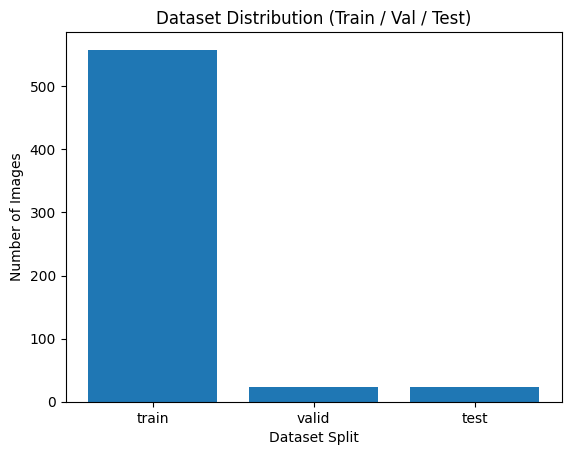

train Images: 558
valid Images: 23
test Images: 23


In [4]:
import os
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/dental-opg/dataset"

folders = ["train", "valid", "test"]  

image_counts = []

for folder in folders:
    folder_path = os.path.join(dataset_path, folder, "images")
    
    count = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith((".jpg", ".jpeg", ".png")):
                count += 1
                
    image_counts.append(count)

# Bar Chart
plt.figure()
plt.bar(folders, image_counts)
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution (Train / Val / Test)")
plt.show()

# Print also
for f, c in zip(folders, image_counts):
    print(f"{f} Images:", c)

In [6]:
model = YOLO("yolov8l.pt")

results = model.train(
    data=DATA_YAML,
    epochs=550,
    imgsz=640,
    batch=32,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    patience=100,
    device=0,
    amp=True,
    workers=4,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    cls=1.5,
    project="Dental_OPG",
    name="yolov8_single_training"
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/dental-opg/dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=550, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_single_training2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

In [7]:
best_model = YOLO("/kaggle/working/runs/detect/Dental_OPG/yolov8_single_training2/weights/best.pt")

metrics = best_model.val()

print("\n===== VALIDATION RESULTS =====\n")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 113 layers, 43,611,234 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 78.0±26.2 MB/s, size: 40.9 KB)
val: Scanning /kaggle/input/dental-opg/dataset/valid/labels... 23 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 203.2it/s 0.1s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/dental-opg/dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s1.0s
                   all         23        115      0.951      0.919      0.961       0.71
         Healthy Teeth          8         14      0.851          1      0.952      0.691
                Caries          3          4          1       0.77      0.995       0.77
        Impacted Teeth          7         18      0.968          1      0.995      0.719
         

In [8]:
test_results = best_model.val(data=DATA_YAML, split="test")

print("\n===== TEST RESULTS =====\n")
print(test_results)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 10.8±7.9 ms, read: 1.3±0.3 MB/s, size: 40.9 KB)
val: Scanning /kaggle/input/dental-opg/dataset/test/labels... 23 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 52.8it/s 0.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/dental-opg/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 1.0s1.4s
                   all         23        102       0.97      0.934      0.978      0.773
         Healthy Teeth         14         26      0.998      0.885      0.948       0.75
                Caries          2          5      0.987          1      0.995      0.791
        Impacted Teeth          7         12      0.998          1      0.995      0.751
             Infection          4          5      0.893          1      0.995      0.827
       

In [9]:
results = best_model.predict(
    source="/kaggle/input/dental-opg/dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)



image 1/23 /kaggle/input/dental-opg/dataset/test/images/104_jpg.rf.05501644f89b63b3f9ba38f2c2436c75.jpg: 352x640 1 Healthy Teeth, 1 Impacted Teeth, 58.1ms
image 2/23 /kaggle/input/dental-opg/dataset/test/images/106_jpg.rf.55f75c16fffc0fea03b260bf91b8fc68.jpg: 352x640 2 Infections, 2 Fractured Teeths, 17.5ms
image 3/23 /kaggle/input/dental-opg/dataset/test/images/127_jpg.rf.c6c7a6eea86965354399e338b71fbc6a.jpg: 288x640 2 Healthy Teeths, 1 Impacted Teeth, 4 Fractured Teeths, 48.9ms
image 4/23 /kaggle/input/dental-opg/dataset/test/images/143_jpg.rf.d7f7764bed646dc8d58806a732ef86f4.jpg: 352x640 2 Healthy Teeths, 3 Fractured Teeths, 18.0ms
image 5/23 /kaggle/input/dental-opg/dataset/test/images/146_jpg.rf.416fe5cb77bd045aedfc942be5392ff6.jpg: 320x640 3 Healthy Teeths, 49.0ms
image 6/23 /kaggle/input/dental-opg/dataset/test/images/150_jpg.rf.608ff673ae4ff875b58580c08f0ae389.jpg: 416x640 1 Healthy Teeth, 2 Fractured Teeths, 48.1ms
image 7/23 /kaggle/input/dental-opg/dataset/test/images/157_j

In [10]:
import shutil

# Path to the folder you want to compress
folder_path = '/kaggle/working/runs'
zip_path = '/kaggle/working/runs.zip'

# Compress the folder into a zip file
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

# The file can now be downloaded from the output directory
zip_path

'/kaggle/working/runs.zip'